<a href="https://colab.research.google.com/github/Saphythrix/IIT-SUMMER-INTERNSHIP/blob/main/CIFAR_10_image_Gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
torch.manual_seed(42)

In [ ]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5,0.5,0.5),
        std=(0.5,0.5,0.5)
    ),
    transforms.Lambda(lambda x:x.view(3,-1))
])

In [ ]:
train_dataset=torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
test_dataset=torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:03<00:00, 44.7MB/s]


In [ ]:
train_loader=DataLoader(train_dataset,batch_size=512,shuffle=True,pin_memory=True,num_workers=4)
test_loader=DataLoader(test_dataset,batch_size=512,shuffle=False,pin_memory=True,num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
CLASSES = train_dataset.classes
C = len(CLASSES)
print(f"Classes: {CLASSES}")
print(f"Input shape per sample: {train_dataset[0][0].shape}")

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Input shape per sample: torch.Size([3, 1024])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

#Bulding the model
class TemporalCNN1D(nn.Module):

  def __init__(self,num_classes=10,dropout_p=0.5):
      super().__init__()

      def conv_block(input_ch,output_ch,apply_drop=True):
          layers=[
              nn.Conv1d(input_ch,output_ch,kernel_size=3,padding=1),
              nn.BatchNorm1d(output_ch,affine=True),
              nn.LeakyReLU(negative_slope=0.3)
          ]
          if apply_drop:
            layers.append(nn.Dropout(p=dropout_p))
          return nn.Sequential(*layers)

      self.encoder=nn.Sequential(
          conv_block(3,32,apply_drop=True),
          conv_block(32,64,apply_drop=True),
          conv_block(64,64,apply_drop=True),
          conv_block(64,128,apply_drop=True),
          conv_block(128,128,apply_drop=True),
          conv_block(128,100,apply_drop=False)
      )

      self.pool=nn.AdaptiveAvgPool1d(1)

      self.classifer=nn.Linear(100,num_classes)

  def forward(self,x):
      features=self.encoder(x)
      pooling=self.pool(features)
      flatten=pooling.squeeze(-1)
      logit=self.classifer(flatten)
      return logit

  def get_features(self,x):
      features=self.encoder(x)
      pooled=self.pool(features)

      return pooled.squeeze(-1)

In [ ]:
learning_rate = 0.001
epochs = 25

In [ ]:
model=TemporalCNN1D(num_classes=10,dropout_p=0.5).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=learning_rate)

In [ ]:
#training loop
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []} # Initialize history

for epoch in range(epochs):
  # Training
  model.train()
  total_train_loss = 0
  correct_train_predictions = 0
  total_train_samples = 0

  for inputs,labels in train_loader:
    inputs,labels=inputs.to(device),labels.to(device)

    # forward pass
    output=model(inputs)
    loss=criterion(output,labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_train_loss += loss.item() * inputs.size(0)
    correct_train_predictions    += (output.argmax(dim=1) == labels).sum().item() # Use output instead of logits
    total_train_samples      += inputs.size(0)

  # Calculate epoch-level metrics
  avg_train_loss = total_train_loss / total_train_samples
  train_accuracy = correct_train_predictions / total_train_samples
  history["train_loss"].append(avg_train_loss)
  history["train_acc"].append(train_accuracy)

  # Validation
  model.eval()
  total_val_loss = 0
  correct_val_predictions = 0
  total_val_samples = 0

  with torch.no_grad():
    for inputs, labels in test_loader: # Assuming test_loader is the validation loader
      inputs, labels = inputs.to(device), labels.to(device)
      output = model(inputs)
      loss = criterion(output, labels)

      total_val_loss += loss.item() * inputs.size(0)
      correct_val_predictions += (output.argmax(dim=1) == labels).sum().item()
      total_val_samples += inputs.size(0)

  avg_val_loss = total_val_loss / total_val_samples
  val_accuracy = correct_val_predictions / total_val_samples
  history["val_loss"].append(avg_val_loss)
  history["val_acc"].append(val_accuracy)

  print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f} | Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/25 - Train Loss: 1.9685, Train Acc: 0.2681 | Val Loss: 1.9894, Val Acc: 0.2651
Epoch 2/25 - Train Loss: 1.8459, Train Acc: 0.3247 | Val Loss: 1.8659, Val Acc: 0.3238
Epoch 3/25 - Train Loss: 1.7738, Train Acc: 0.3582 | Val Loss: 1.8093, Val Acc: 0.3452
Epoch 4/25 - Train Loss: 1.7210, Train Acc: 0.3838 | Val Loss: 1.7595, Val Acc: 0.3644
Epoch 5/25 - Train Loss: 1.6758, Train Acc: 0.4001 | Val Loss: 1.8503, Val Acc: 0.3553
Epoch 6/25 - Train Loss: 1.6446, Train Acc: 0.4122 | Val Loss: 1.6609, Val Acc: 0.4145
Epoch 7/25 - Train Loss: 1.6229, Train Acc: 0.4202 | Val Loss: 1.6855, Val Acc: 0.4100
Epoch 8/25 - Train Loss: 1.6057, Train Acc: 0.4276 | Val Loss: 1.6629, Val Acc: 0.4100
Epoch 9/25 - Train Loss: 1.5899, Train Acc: 0.4360 | Val Loss: 1.6165, Val Acc: 0.4298
Epoch 10/25 - Train Loss: 1.5732, Train Acc: 0.4417 | Val Loss: 1.6270, Val Acc: 0.4285
Epoch 11/25 - Train Loss: 1.5622, Train Acc: 0.4463 | Val Loss: 1.6082, Val Acc: 0.4343
Epoch 12/25 - Train Loss: 1.5513, Train A

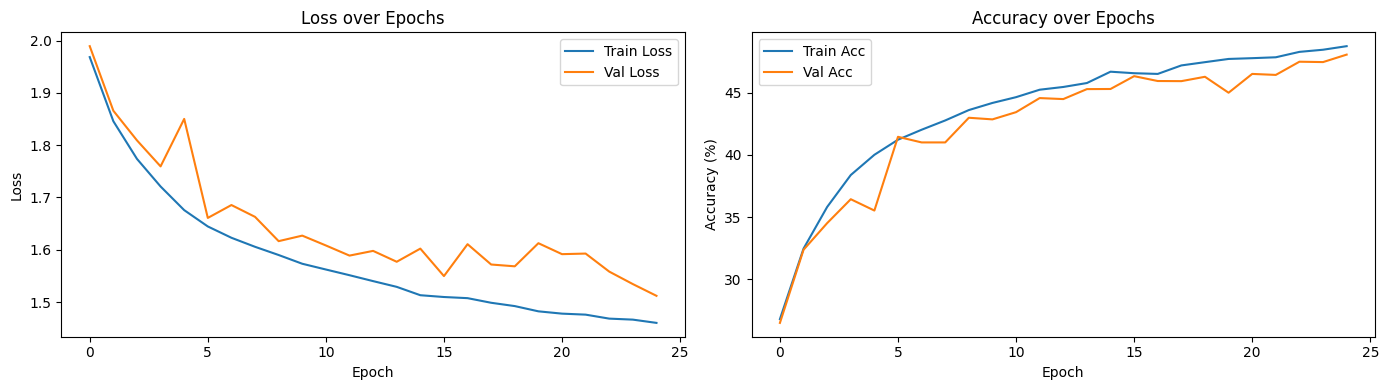

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history["train_loss"], label="Train Loss")
ax1.plot(history["val_loss"],   label="Val Loss")
ax1.set_title("Loss over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot([a*100 for a in history["train_acc"]], label="Train Acc")
ax2.plot([a*100 for a in history["val_acc"]],   label="Val Acc")
ax2.set_title("Accuracy over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:

print(model)
last_layer=list(model.children())[-1]
print(last_layer)

TemporalCNN1D(
  (encoder): Sequential(
    (0): Sequential(
      (0): Conv1d(3, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.3)
      (3): Dropout(p=0.5, inplace=False)
    )
    (1): Sequential(
      (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.3)
      (3): Dropout(p=0.5, inplace=False)
    )
    (2): Sequential(
      (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.3)
      (3): Dropout(p=0.5, inplace=False)
    )
    (3): Sequential(
      (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, af

 Reference Gradient (g_s)

In [ ]:
model.eval()
x_train_batch, y_train_batch = next(iter(train_loader))
print(x_train_batch.shape)
print(y_train_batch.shape)

ref_images=x_train_batch.to(device)
ref_labels=y_train_batch.to(device)

model.zero_grad()
#forward propagation
output=model(ref_images)

#loss calculation
loss=criterion(output,ref_labels)


loss.backward()

g_s=last_layer.weight.grad.detach().cpu().numpy().flatten()
print(g_s.shape)
print(g_s)
last_layer.weight.shape

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([512, 3, 1024])
torch.Size([512])
(1000,)
[-1.31518953e-02 -8.87365732e-03 -1.27848042e-02 -8.23922083e-03
 -6.44051749e-03 -1.21315029e-02 -1.22208297e-02 -8.38059932e-03
 -9.87150986e-03 -1.01160947e-02 -1.29043581e-02 -1.64667070e-02
 -4.05625207e-03 -4.42034751e-03 -7.64939096e-03 -7.69591797e-03
 -1.55562852e-02 -3.33633297e-03 -1.60697065e-02 -5.68648847e-03
 -1.69728547e-02 -1.18984543e-02 -8.73265974e-03 -6.53751800e-03
 -1.81056429e-02 -1.53335473e-02 -5.75491041e-03 -3.21583194e-03
 -9.32824053e-03 -3.77151114e-03 -6.22738153e-03 -9.68886632e-03
 -2.25037709e-03 -3.20224511e-03 -1.39025412e-03 -7.89942313e-03
 -4.90741292e-03 -8.66461080e-03 -5.15114050e-03 -1.41214766e-02
 -1.82706844e-02 -8.61022528e-03 -7.58300303e-03 -3.04518477e-03
 -1.31868310e-02 -5.41593786e-03 -1.05014825e-02 -5.17753419e-03
 -7.07583968e-03 -1.30038233e-02 -1.83580313e-02 -1.21065266e-02
 -1.53494440e-02 -3.76728573e-03 -1.01850033e-02 -4.73131519e-03
 -8.79532564e-03 -3.60543490e-03 -1.1

torch.Size([10, 100])

Runtime Gradient (g_m)

In [ ]:
x_test_batch, y_test_batch = next(iter(test_loader))
x_test_batch=x_test_batch.to(device)
y_test_batch=y_test_batch.to(device)
model.eval()
model.zero_grad()

output=model(x_test_batch)
loss=criterion(output,y_test_batch)

loss.backward()

g_m=last_layer.weight.grad.detach().cpu().numpy().flatten()
print(g_m)
print(g_m.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[-9.78645217e-03 -1.21739078e-02 -1.22793382e-02 -1.36062112e-02
 -1.06128510e-02 -1.16530117e-02 -8.92385095e-03 -1.57134309e-02
 -9.80379526e-03 -1.70462877e-02 -1.61789544e-02 -1.00355847e-02
 -6.16217637e-03 -6.08175853e-03 -1.53966583e-02 -1.51911099e-02
 -1.05383825e-02 -9.81928222e-03 -1.64551456e-02 -1.16674826e-02
 -1.34308618e-02 -1.27495881e-02 -1.37966517e-02 -6.85749575e-03
 -1.20067019e-02 -9.17085633e-03 -1.76057015e-02 -5.35695395e-03
 -1.25574227e-02 -7.80301727e-03 -1.01977559e-02 -6.47101272e-03
 -4.91716247e-03 -1.11255525e-02 -8.67314544e-03 -1.22334138e-02
 -1.27582299e-02 -1.55055476e-02 -8.06172099e-03 -1.15290098e-02
 -1.20182708e-02 -8.95409752e-03 -1.48594650e-02 -7.21442141e-03
 -1.31457560e-02 -1.06060356e-02 -1.40945148e-02 -1.48291346e-02
 -6.24712231e-03 -1.09713217e-02 -1.12484992e-02 -1.66923143e-02
 -1.17400112e-02 -8.51196330e-03 -3.66376271e-03 -1.04826381e-02
 -1.66141875e-02 -1.21051027e-02 -1.21643115e-02 -9.33231879e-03
 -8.60978384e-03 -1.14200

Gradient Angle

In [ ]:
def gradient_angle(g_s,g_m):
  dot_pro=np.dot(g_s,g_m)
  g_m_norm=np.linalg.norm(g_m)
  g_s_norm=np.linalg.norm(g_s)

  cosine=np.clip(dot_pro/(g_m_norm*g_s_norm),-1.0,1.0)
  angle=np.degrees(np.arccos(cosine))

  return angle

grad_angle=gradient_angle(g_s,g_m)
print(f"Gradient Angle: {grad_angle:.2f}°")

Gradient Angle: 26.42°
